<a href="https://colab.research.google.com/github/ViKing-Coder-jpg/CryptoMoon/blob/main/BackEnd/CryptoMoon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CryptoMoon -A Bitcoin Predictor


# Data Extraction and Library Importing

In [1]:
import sys
print(sys.executable)

!pip3 list

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/bin/python
Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
certifi                 2026.2.25
charset-normalizer      3.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fonttools               4.62.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.11.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
joblib                  1.5.3
jupyter_client          8.8.0
jupyter_core            5.9.1
kagglehub               1.0.0
kagglesdk               0.1.16
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.3
packaging               26.0
pandas                  3.0.1
parso        

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error

In [3]:
import kagglehub
path = kagglehub.dataset_download("aiwithcagri/bitcoin-12-years-price-january-2026")
data= pd.read_csv(path+'/bitcoin (1).csv')
data.shape

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4134, 6)

#Data Cleaning and Preprocessing

In [4]:
print('Empty Cells:',data.isna().sum().sum())
data['Date']=pd.to_datetime(data['Date'])
data.sort_values('Date',inplace=True)
data['Close'].median()


Empty Cells: 0


np.float64(10795.1455078125)

#Feature Engineering and train-test splitting

In [5]:

featData=pd.DataFrame()
featData['Close']=data['Close']

featData['SMA_20']=data['Close'].rolling(window=20).mean()
featData['SMA_20_y']=featData['SMA_20'].shift(1)
featData['SMA_50']=data['Close'].rolling(window=50).mean()
featData['SMA_50_y']=featData['SMA_50'].shift(1)

featData['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
featData['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
featData['MACD'] = featData['EMA_12'] - featData['EMA_26']

delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / (avg_loss + 1e-9)
featData['RSI'] = 100 - (100 / (1 + rs))

featData['Returns']=data['Close'].pct_change()
featData['Close_SMA20_Ratio']=data['Close']/featData['SMA_20'].shift(1)
featData['Close_SMA50_Ratio']=data['Close']/featData['SMA_50'].shift(1)
featData['SMA_Cross']=np.where(((featData['SMA_20']>featData['SMA_50'])& (featData['SMA_20_y']<=featData['SMA_50_y'])),1,np.where(((featData['SMA_20']<featData['SMA_50'])& (featData['SMA_20_y']>featData['SMA_50_y'])),-1,0))
featData['MACD_signal']=featData['MACD'].ewm(span=9, adjust=False).mean()
featData['MACD_histogram']=featData['MACD']-featData['MACD_signal']
featData['RSI_signal']=np.where(featData['RSI']>70,1,np.where(featData['RSI']<30,-1,0))
featData['Volume_change']=data['Volume'].pct_change()
featData['Volume_SMA_20'] = data['Volume'].rolling(window=20).mean()
featData['Volume_SMA_20_Ratio'] = data['Volume'] / featData['Volume_SMA_20'].shift(1)
featData['Lag_1']=featData['Returns'].shift(1)
featData['Lag_2']=featData['Returns'].shift(2)
featData['Lag_3']=featData['Returns'].shift(3)
featData['Lag_5']=featData['Returns'].shift(5)
featData['Lag_7']=featData['Returns'].shift(7)
featData['Volatility_5']=featData['Returns'].rolling(window=5).std()
featData['Volatility_10']=featData['Returns'].rolling(window=10).std()
featData['HL_Range_pct'] = (data['High'] - data['Low']) / data['Close']
featData['OC_Range_pct'] = (data['Close'] - data['Open']) / data['Open']
featData['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
featData['Close_EMA20_diff'] = (data['Close'] - featData['EMA_20']) / data['Close']

featData['Target'] = featData['Returns'].shift(-1)
# featData['Target'] = featData['Returns'].rolling(3).mean().shift(-3)
featData.dropna(inplace=True)
featData.reset_index(drop=True,inplace=True)
# print(featData['Target'].describe())
# print(featData[['Close', 'Target']].head(10))
featData.drop(['SMA_20','SMA_50','SMA_20_y','SMA_50_y','EMA_12','EMA_20','EMA_26','Close','MACD_signal','RSI_signal','SMA_Cross','Volume_SMA_20'],axis=1,inplace=True)



In [7]:

y=featData['Target']
X=featData.drop('Target',axis=1)


In [8]:
print(X.columns.tolist())
joblib.dump(X.columns.tolist(), 'feature_names.joblib')

['MACD', 'RSI', 'Returns', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'MACD_histogram', 'Volume_change', 'Volume_SMA_20_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Volatility_5', 'Volatility_10', 'HL_Range_pct', 'OC_Range_pct', 'Close_EMA20_diff']


['feature_names.joblib']

In [9]:

split_point = int(len(X) * 0.8)


X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]



# Model Training and Testing
  Using XGBoost as Base ML Model



In [10]:
model=XGBRegressor(
     n_estimators=1000,
    learning_rate=0.02,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:pseudohubererror'
)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


In [11]:
joblib.dump(model, 'XGBoost_model.joblib')

['XGBoost_model.joblib']

Filtered Accuracy: 0.5448275862068965
Trade %: 0.17747858017135862


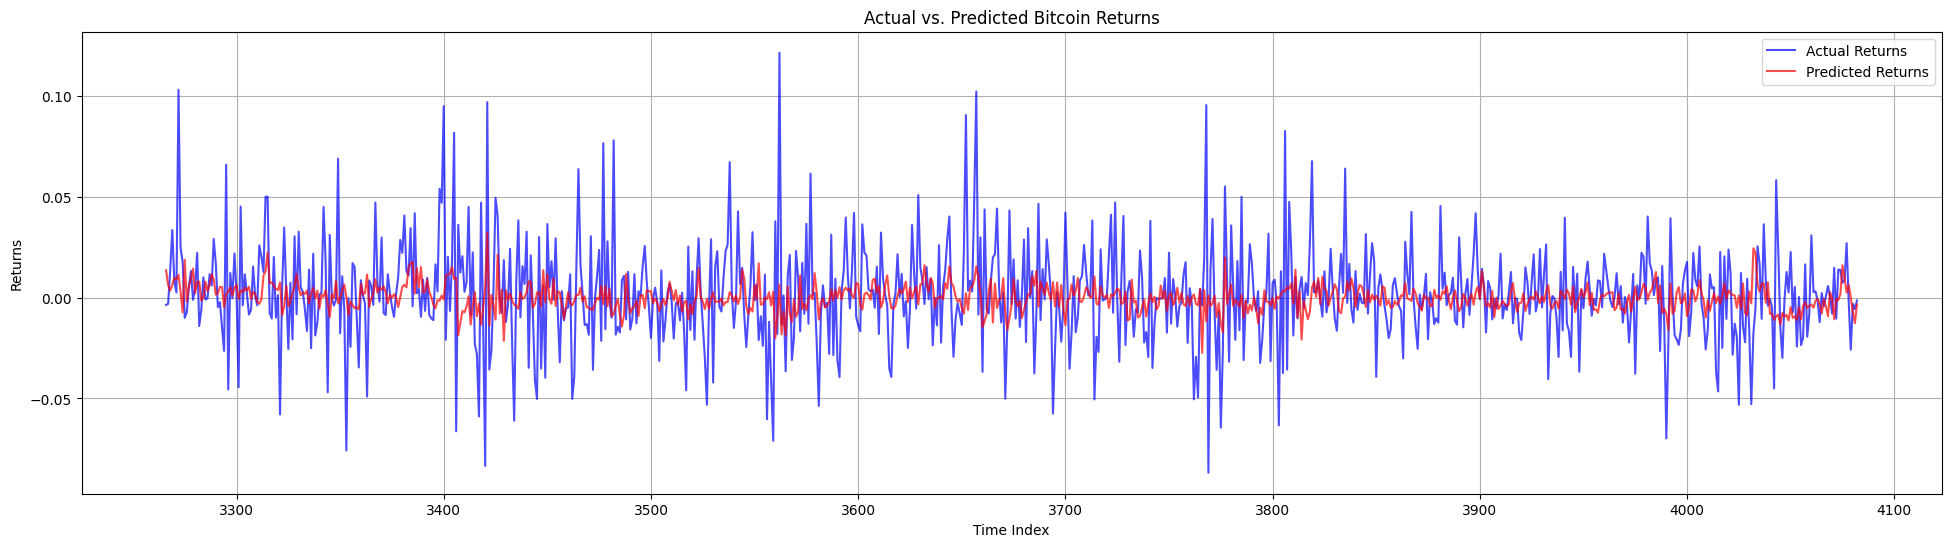

In [12]:
threshold = 0.008

signals = np.where(y_pred > threshold, 1,
          np.where(y_pred < -threshold, -1, 0))

mask = signals != 0

direction_acc = np.mean((signals[mask] > 0) == (y_test[mask] > 0))

print("Filtered Accuracy:", direction_acc)
print("Trade %:", np.mean(mask))


plt.figure(figsize=(24, 6))
plt.plot(y_test.index, y_test, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()


Direction Accuracy:     51.16%
Sharpe Ratio:           1.319
Max Drawdown:           -32.15%
Final Strategy Return:  3.172x
Final Market Return:    3.169x


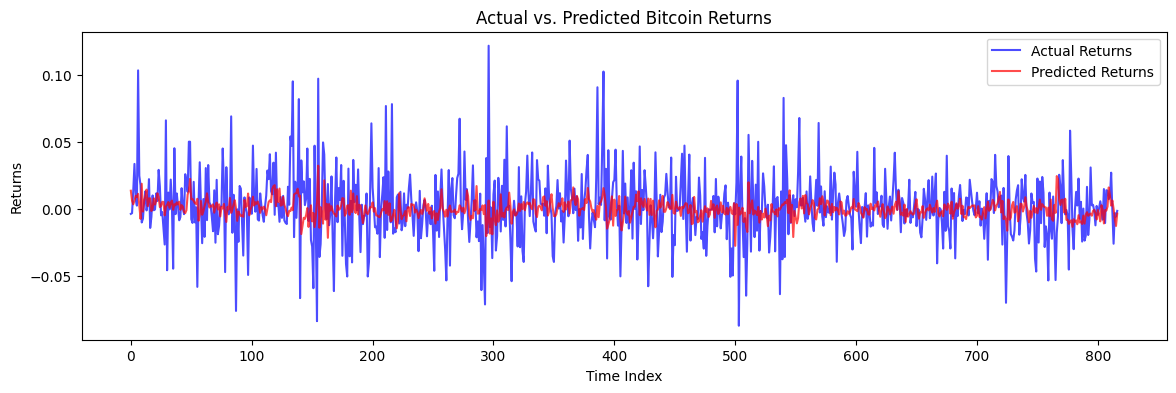

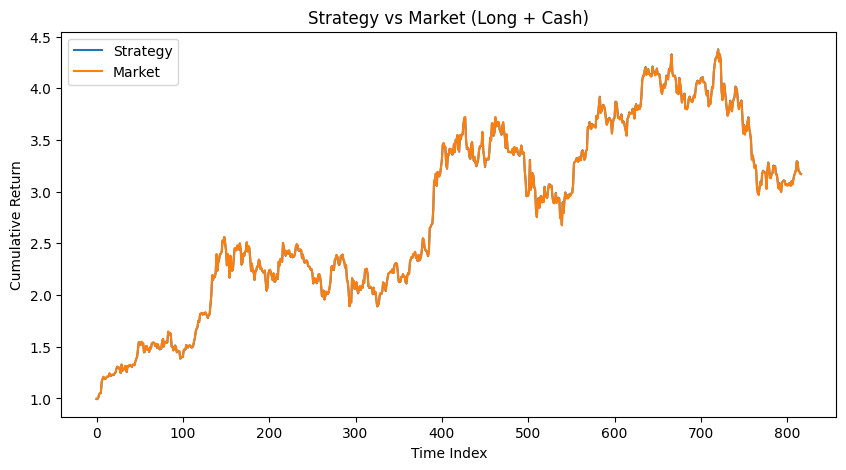

In [13]:
threshold_enter = 0.001
threshold_exit = -0.025   # exit to cash if pred < this
                          # between the two = hold current position

position = np.zeros(len(y_pred))
current_pos = 1  # start invested

for i in range(len(y_pred)):
    if y_pred[i] > threshold_enter:
        current_pos = 1   # go/stay long
    elif y_pred[i] < threshold_exit:
        current_pos = 0   # exit to cash
    position[i] = current_pos

# Apply returns
strategy_returns = position * y_test.values

# Transaction cost only when position changes
trades = np.abs(np.diff(position, prepend=0))
cost = 0.001
strategy_returns = strategy_returns - cost * trades

# Cumulative
cumulative_strategy = pd.Series((1 + strategy_returns).cumprod())
cumulative_market = pd.Series((1 + y_test.values).cumprod())

# ----------------------------------------
# METRICS
# ----------------------------------------
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365)
drawdown = (cumulative_strategy / cumulative_strategy.cummax() - 1).min()
direction_acc = np.mean((y_pred > 0) == (y_test.values > 0))

print(f"Direction Accuracy:     {direction_acc:.2%}")
print(f"Sharpe Ratio:           {sharpe:.3f}")
print(f"Max Drawdown:           {drawdown:.2%}")
print(f"Final Strategy Return:  {cumulative_strategy.iloc[-1]:.3f}x")
print(f"Final Market Return:    {cumulative_market.iloc[-1]:.3f}x")

# ----------------------------------------
# PLOT 1 - Actual vs Predicted Returns
# ----------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(y_test.values, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.show()

# ----------------------------------------
# PLOT 2 - Strategy vs Market
# ----------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(cumulative_strategy, label='Strategy')
plt.plot(cumulative_market, label='Market')
plt.legend()
plt.title('Strategy vs Market (Long + Cash)')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Return')
plt.show()